# IS362 Project 2

Leveraging Pandas to tidy data and extrapolate useful insights

DataSet 1: Salary Survey

My first dataset is my own which includes salary information I will
- Tidy this data up for easier insights
- Leverage this tidy data to examine the relationship between education level and salary if any
- Build a bar chart showcasing this information

In [26]:
# Import Modules

import pandas as pd
import os
import matplotlib.pyplot as plt
ss = "salary_survey.csv"

if not os.path.exists(ss):
    url = "https://docs.google.com/spreadsheets/d/1IPS5dBSGtwYVbjsfbaMCYIWnOuRmJcbequohNxCyGVw/export?format=csv&gid=1625408792"
    surveys = pd.read_csv(url)
    surveys.to_csv(ss, index=False)
    print("Downloaded and saved locally")
else:
    surveys = pd.read_csv(ss)
    print("Loaded from local file")

# Print the top rows of the survey for initial investigation
surveys.head()

Loaded from local file


,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:",What is your annual salary?,"How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",What country do you work in?,"If you're in the U.S., what state do you work in?",What city do you work in?,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,What is your race? (Choose all that apply.)
0,4/27/2021 11:02,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


Now I will use Pandas to tidy up columns and provide insightful education data 

In [27]:
column_names = {
    'How old are you?': 'age',
    'What industry do you work in?': 'industry',
    'Job title': 'title',
    'What is your annual salary?': 'salary',
    'What country do you work in?': 'country',
    'How many years of professional work experience do you have in your field?': 'experience',
    'What is your highest level of education completed?': 'education',
    'What is your gender?': 'gender',
    'Please indicate the currency': 'currency'
}

education_order = [
    'High School',
    'Some college', 
    'College degree',
    "Master's degree",
    'Professional degree (MD, JD, etc.)',
    'PhD'
]

surveys = (pd.read_csv("salary_survey.csv")
    .rename(columns=column_names)
    .dropna(subset=["salary", "education"])
    [["age", "industry", "title", "salary", "education", "gender", "currency"]]
    .assign(salary=lambda x: pd.to_numeric(
        x["salary"].str.replace(",", "").str.strip(), errors="coerce"))
    .dropna(subset=["salary"])
    .query("currency == 'USD'")
    .query("10000 <= salary <= 500000")
)

print(surveys.shape)
print(surveys["education"].value_counts())

(23151, 7)
education
College degree                        11325
Master's degree                        7505
Some college                           1644
Professional degree (MD, JD, etc.)     1131
PhD                                    1127
High School                             419
Name: count, dtype: int64


Here I will correlate education level to salary. Doing this will help me in my final step of creating a bar chart to provide a visual representation of this information

In [28]:
# Calculate mean salary by education level
edu_salary = (surveys
    .groupby("education")["salary"]
    .mean()
    .reindex(education_order)  # apply logical order
    .round(2)
)

print(edu_salary)

education
High School                            73075.51
Some college                           76456.43
College degree                         86097.73
Master's degree                        91282.34
Professional degree (MD, JD, etc.)    136436.24
PhD                                   108398.37
Name: salary, dtype: float64


Now I will create a bar chart to visualize this data and provide actionable information regarding the affect of education level on salary

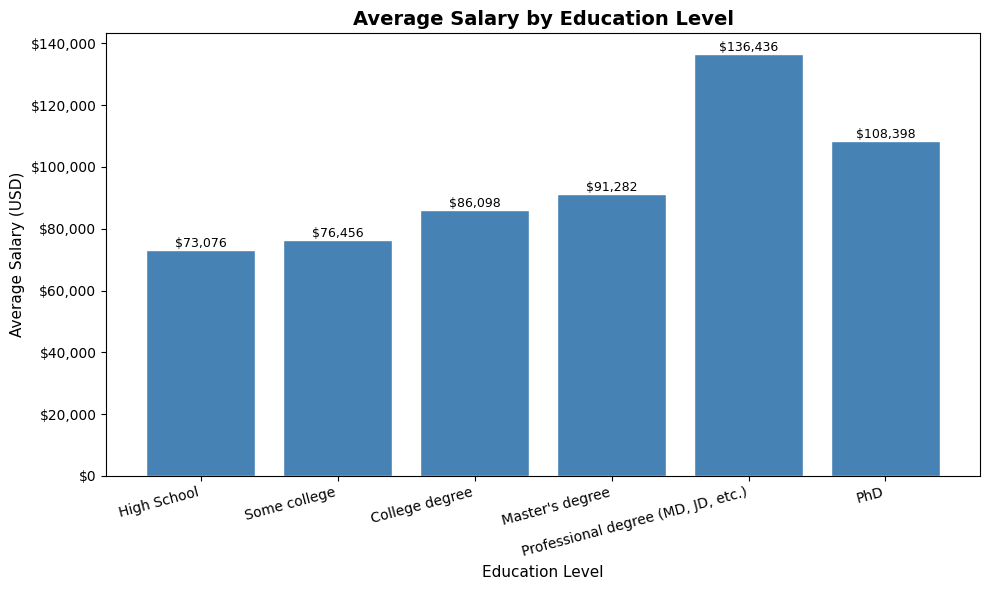

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(education_order, edu_salary.values, color="steelblue", edgecolor="white")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}',
            ha='center', va='bottom', fontsize=9)

ax.set_title("Average Salary by Education Level", fontsize=14, fontweight="bold")
ax.set_xlabel("Education Level", fontsize=11)
ax.set_ylabel("Average Salary (USD)", fontsize=11)
ax.set_xticks(range(len(education_order)))
ax.set_xticklabels(education_order, rotation=15, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

Looking at this simple bar chart we can observe a clear corrolation between education level and salary with salary steadily increasing alongside education attainment. There is an oberservable drop between professional degree and PhD ~ $28,000 which could be attributed to profession.

Let's perform a quick query to confirm that.

In [30]:
advanced = surveys[surveys["education"].isin([
    "Professional degree (MD, JD, etc.)",
    "PhD"
])]

print(advanced.shape)

print(advanced.groupby("education")["title"]
      .value_counts()
      .groupby(level=0)
      .head(10))

(2258, 7)
education                           title                    
PhD                                 Assistant Professor          57
                                    Associate Professor          32
                                    Professor                    22
                                    Scientist                    19
                                    Assistant Professor          14
                                    Director                     14
                                    Research Scientist           14
                                    Lecturer                     11
                                    Assistant professor          11
                                    Data Scientist               11
Professional degree (MD, JD, etc.)  Attorney                     85
                                    Associate Attorney           53
                                    Associate                    40
                                    Partner 

Looking at the top 10 most common job titles for each group we see PhD holders skew toward the eduction field and Professional degree holders in various levels of the medical and law fields.

DataSet 2: Retail Shopper